# Introdução à Ciência de Dados e IA Preditiva (Python)
### Minicurso — X Semana do PIEPEX · ICSA
**Alice Duarte**

Este notebook acompanha os exemplos da aula.

**Como usar:** aperte `Shift + Enter` para rodar uma célula, ou vá em **Ambiente de execução → Executar tudo**. Pode editar à vontade — se algo quebrar, é só recarregar a página.

## 1. Os pacotes que vamos usar
No Colab eles já vêm instalados. Cada um tem um papel:
- `pandas` — a tabela de dados (DataFrame)
- `numpy` — cálculo numérico
- `matplotlib` / `seaborn` — gráficos
- `scikit-learn` — machine learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)  # deixa os sorteios reprodutíveis
print("Pacotes carregados! \u2705")

Pacotes carregados! ✅


## 2. Carregando uma base real
Base de **custos de seguro-saúde**: cada linha é uma pessoa, com idade, sexo, IMC, nº de filhos, se fuma, região e o **custo cobrado (`charges`)** — nossa variável de interesse.

A base: "Medical Cost Personal Dataset" (insurance.csv)

É um conjunto clássico de ensino, que aparece no livro Machine Learning with R (Brett Lantz). São dados simulados a partir de padrões demográficos reais dos EUA — não são registros de pacientes reais.

As 7 colunas:

age — idade, número inteiro de 18 a 64 anos (média 39).
sex — sexo, texto: male (676) / female (662) — bem equilibrado.
bmi — IMC (índice de massa corporal), decimal de 15,96 a 53,13 (média 30,7 — já na faixa de sobrepeso/obesidade).
children — nº de dependentes cobertos, inteiro de 0 a 5 (a maioria tem 0 ou 1).
smoker — fumante, texto: no (1.064) / yes (apenas 274, ~20%).
region — região nos EUA: southeast, southwest, northwest, northeast (bem distribuídas).
charges — o custo anual cobrado, em dólares — é o que os modelos preveem. Varia de US$ 1.122 a US$ 63.770 (média ~US$ 13.270, mediana ~US$ 9.382 — cauda longa à direita).

In [3]:
URL = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(URL)

print("Formato (linhas, colunas):", df.shape)
df.head()

Formato (linhas, colunas): (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
#from google.colab import sheets
#sheet = sheets.InteractiveSheet(df=df)

MessageError: Error: credential propagation was unsuccessful

## 3. Análise Exploratória (EDA)
Antes de qualquer modelo: **conhecer os dados**. Médias, distribuições e relações entre variáveis.

In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


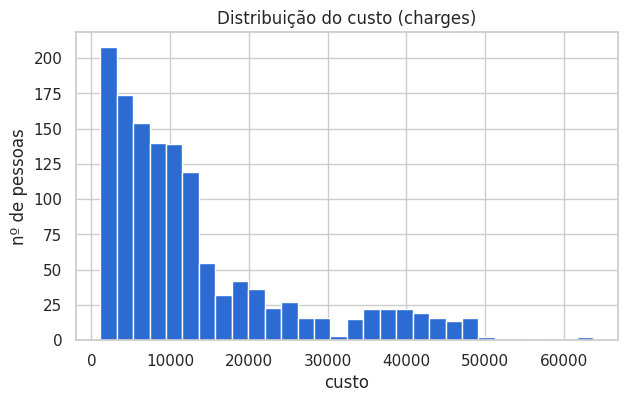

In [5]:
# Distribuição do custo
plt.figure(figsize=(7, 4))
plt.hist(df["charges"], bins=30, color="#2C6BD4")
plt.title("Distribuição do custo (charges)")
plt.xlabel("custo"); plt.ylabel("nº de pessoas")
plt.show()

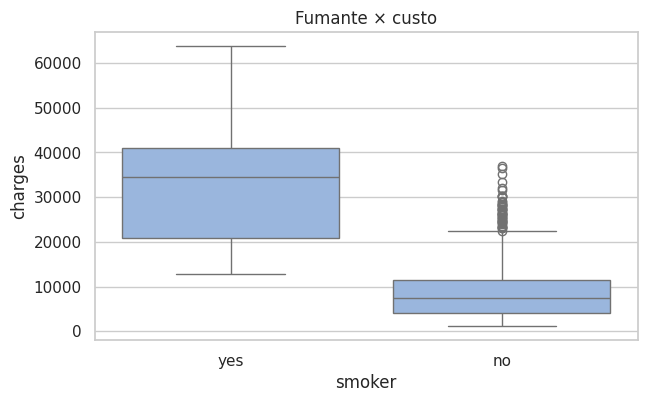

In [6]:
# Fumantes custam mais?
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="smoker", y="charges", color="#8FB4E8")
plt.title("Fumante \u00d7 custo")
plt.show()

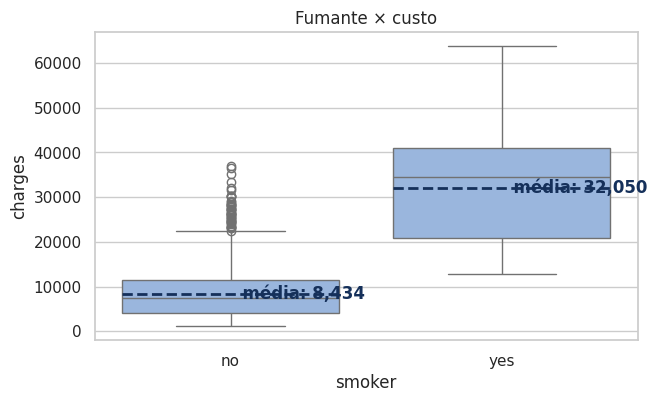

In [9]:
# Fumantes custam mais?
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df, x="smoker", y="charges", order=["no", "yes"],
    color="#8FB4E8",
    showmeans=True, meanline=True,                     # desenha a linha da média em cada caixa
    meanprops={"color": "#15305A", "linewidth": 2, "linestyle": "--"},
)

# escreve o valor da média ao lado de cada caixa
for i, grupo in enumerate(["no", "yes"]):
    media = df.loc[df["smoker"] == grupo, "charges"].mean()
    plt.text(i, media, f"  média: {media:,.0f}", color="#15305A",
             va="center", fontweight="bold")

plt.title("Fumante × custo")
plt.show()

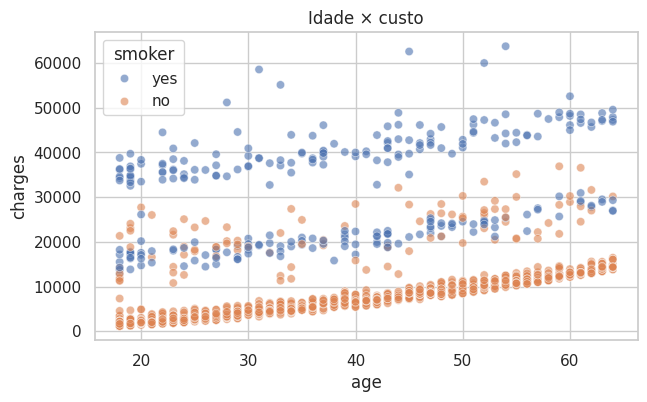

In [10]:
# Idade e custo, separando fumantes
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", alpha=0.6)
plt.title("Idade \u00d7 custo")
plt.show()

> **Experimente:** troque `x="smoker"` por `x="region"` no boxplot. A região muda muito o custo?

## 4. Determinístico x Estocástico
Dois jeitos de projetar o futuro de um valor (imagine uma reserva ou uma carteira).

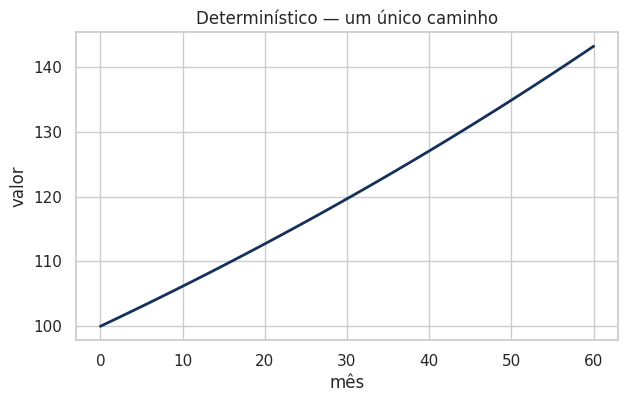

In [12]:
# DETERMINÍSTICO: taxa fixa -> um único caminho (auditável)
meses = 60
inicio = 100
taxa = 0.006  # 0,6% ao mês

valor = [inicio]
for _ in range(meses):
    valor.append(valor[-1] * (1 + taxa))

plt.figure(figsize=(7, 4))
plt.plot(valor, color="#15305A", linewidth=2)
plt.title("Determinístico \u2014 um único caminho")
plt.xlabel("mês"); plt.ylabel("valor")
plt.show()

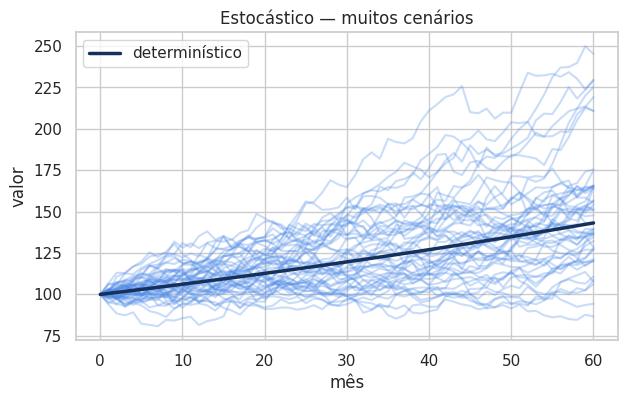

In [13]:
# ESTOCÁSTICO: a cada mês a taxa varia -> muitos cenários possíveis
plt.figure(figsize=(7, 4))
for _ in range(50):
    v = [inicio]
    for _ in range(meses):
        r = np.random.normal(0.006, 0.03)   # média 0,6% com incerteza
        v.append(v[-1] * (1 + r))
    plt.plot(v, color="#4F8BE8", alpha=0.3)

plt.plot(valor, color="#15305A", linewidth=2.5, label="determinístico")
plt.legend(); plt.title("Estocástico \u2014 muitos cenários")
plt.xlabel("mês"); plt.ylabel("valor")
plt.show()

## 5. Monte Carlo: do leque aos cenários
Repetimos a simulação milhares de vezes e olhamos a **distribuição** do resultado final. Dela tiramos o cenário **pessimista (p5)**, **base (mediana)** e **otimista (p95)** — e a probabilidade de perda.

Pessimista (p5):   80.9
Base (mediana):   104.8
Otimista (p95):   136.0
Prob. de perda:   38%


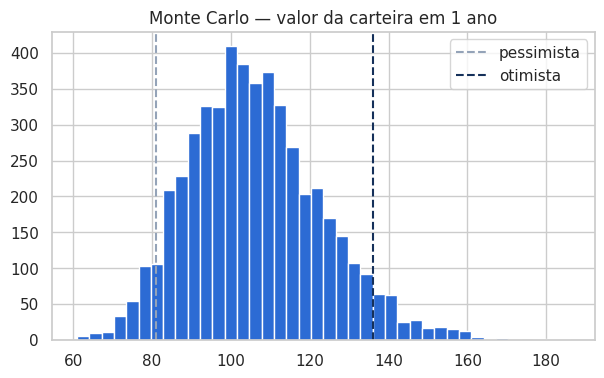

In [14]:
n_sim = 5000
finais = []
for _ in range(n_sim):
    v = 100
    for _ in range(12):          # 12 meses
        v *= 1 + np.random.normal(0.005, 0.045)
    finais.append(v)
finais = np.array(finais)

pessimista, base, otimista = np.percentile(finais, [5, 50, 95])
print(f"Pessimista (p5):  {pessimista:5.1f}")
print(f"Base (mediana):   {base:5.1f}")
print(f"Otimista (p95):   {otimista:5.1f}")
print(f"Prob. de perda:   {(finais < 100).mean():.0%}")

plt.figure(figsize=(7, 4))
plt.hist(finais, bins=40, color="#2C6BD4")
plt.axvline(pessimista, color="#94A3B8", linestyle="--", label="pessimista")
plt.axvline(otimista, color="#15305A", linestyle="--", label="otimista")
plt.legend(); plt.title("Monte Carlo \u2014 valor da carteira em 1 ano")
plt.show()

> Rode a célula de novo: os números mudam um pouco a cada vez — é o acaso em ação. Aumente `n_sim` e veja a distribuição ficar mais estável.

## 6. IA Preditiva: prevendo o custo
Um modelo de **machine learning** que aprende com o histórico e prevê o custo de uma pessoa a partir das características dela.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1) transformar texto em número (fumante, sexo, região)
dados = pd.get_dummies(df, drop_first=True)

# 2) separar o que explica (X) do que queremos prever (y)
X = dados.drop(columns="charges")
y = dados["charges"]

# 3) treino e teste
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# 4) treinar
modelo = RandomForestRegressor(n_estimators=300, random_state=42)
modelo.fit(X_tr, y_tr)

# 5) avaliar
pred = modelo.predict(X_te)
print("R\u00b2  (0 a 1, quanto maior melhor):", round(r2_score(y_te, pred), 3))
print("Erro médio (MAE):  R$", round(mean_absolute_error(y_te, pred), 2))

R²  (0 a 1, quanto maior melhor): 0.864
Erro médio (MAE):  R$ 2559.94


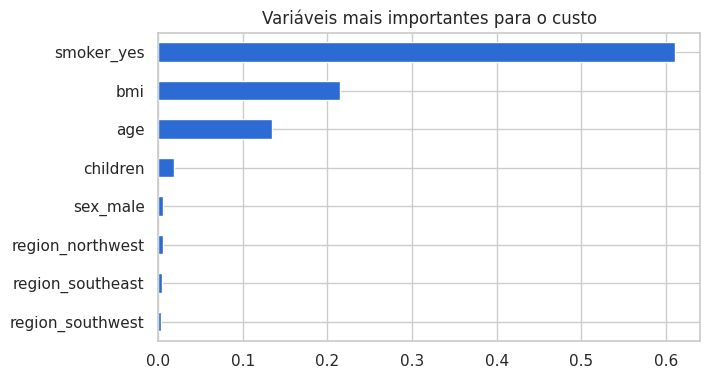

In [19]:
# O que mais pesa na previsão?
importancia = pd.Series(modelo.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(7, 4))
importancia.plot(kind="barh", color="#2C6BD4")
plt.title("Variáveis mais importantes para o custo")
plt.show()

In [26]:
# E uma pessoa nova? (usamos uma linha do teste como molde)
pessoa = X_te.iloc[[0]]
print("Características:")
print(pessoa.T)
print("\nCusto previsto:  R$", round(modelo.predict(pessoa)[0], 2))
print("Custo real:      R$", round(y_te.iloc[0], 2))

Características:
                     764
age                   45
bmi               25.175
children               2
sex_male           False
smoker_yes         False
region_northwest   False
region_southeast   False
region_southwest   False

Custo previsto:  R$ 10243.57
Custo real:      R$ 9095.07


## 7. Sua vez!
Ideias para experimentar:
1. Troque `RandomForestRegressor` por `LinearRegression` e compare o resultado.
2. No Monte Carlo, mude a incerteza (`0.045`) e veja o efeito na probabilidade de perda.
3. Na EDA, descubra qual variável numérica tem maior correlação com `charges` (dica: `df.corr(numeric_only=True)`).


In [29]:
# Dica para o item 1:
from sklearn.linear_model import LinearRegression

#modelo_lin = LinearRegression().fit(X_tr, y_tr)
#print("R\u00b2 (linear):", round(r2_score(y_te, modelo_lin.predict(X_te)), 3))